# CLASIFICACION CON SVM Y NN

En la presente actividad se va a emplear un dataset que contiene información de características de celulares para clasificarlos en un rango de precios.

La información del *dataset* es:
* *battery_power*: Energía total que una batería puede almacenar en un tiempo medido en *mAh*
* *blue*: Indica si tiene *bluetooth* o no
* *clock_speed*: Velocidad del microprocesador
* *dual_sim*: Indica si tiene soporte dual de *sim* o no
* *fc*: Megapíxeles de la cámara frontal
* *four_g*: Indica si tiene 4G o no
* *int_memory*: Memoria interna en GB
* *m_dep*: Grosor del celular en cm
* *mobile_wt*: Peso del celular
* *n_cores*: Número de núcleos del procesador
* *pc*: Megapíxeles de la cámara principal
* *px_height*: Alto de la resolución de píxeles
* *px_width*: Ancho de resolución de píxeles
* *ram*: RAM en MB
* *sc_h*: Alto de la pantalla en cm
* *sc_w*: Ancho de la pantalla en cm
* *talk_time*: tiempo máximo que durará una sola carga de la batería
* *tres_g*: Indica si es 3G o no
* *touch_screen*: Indica si tiene pantalla táctil o no
* *wifi*: Indica si tiene wifi o no
* ***price_range***: Es la variable objetivo con valor 0 (bajo costo), 1 (costo medio), 2 (costo alto) y 3 (costo muy alto).

### IMPORTACIÓN DE LIBRERIAS A UTILIZAR

In [24]:
# ahora si importamos las librerias
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### CARGA DEL DATASET

In [25]:
data = pd.read_csv('/content/drive/MyDrive/archivos CSV/train.csv')

# 1. ANÁLISIS DESCRIPTIVO DE DATOS


## Variables numéricas

In [26]:
#Información de las variables
data.info()
#Resumen estadístico de las variables
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


### **1.1. Escriba el código que permita crear la matriz de correlación de todas las variables numéricas:**

[Text(0.5, 0, 'battery_power'),
 Text(1.5, 0, 'blue'),
 Text(2.5, 0, 'clock_speed'),
 Text(3.5, 0, 'dual_sim'),
 Text(4.5, 0, 'fc'),
 Text(5.5, 0, 'four_g'),
 Text(6.5, 0, 'int_memory'),
 Text(7.5, 0, 'm_dep'),
 Text(8.5, 0, 'mobile_wt'),
 Text(9.5, 0, 'n_cores'),
 Text(10.5, 0, 'pc'),
 Text(11.5, 0, 'px_height'),
 Text(12.5, 0, 'px_width'),
 Text(13.5, 0, 'ram'),
 Text(14.5, 0, 'sc_h'),
 Text(15.5, 0, 'sc_w'),
 Text(16.5, 0, 'talk_time'),
 Text(17.5, 0, 'three_g'),
 Text(18.5, 0, 'touch_screen'),
 Text(19.5, 0, 'wifi'),
 Text(20.5, 0, 'price_range')]

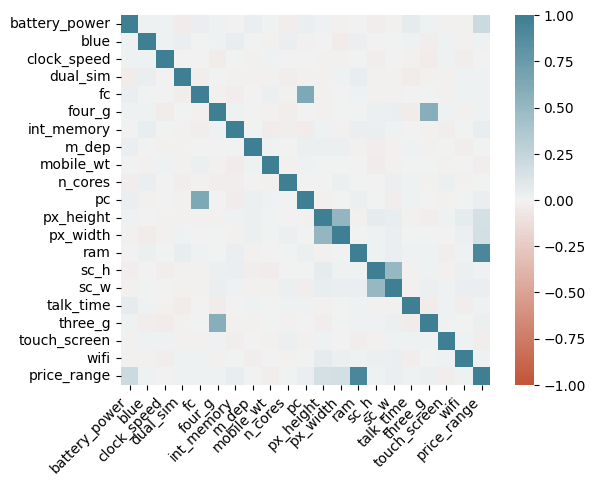

In [27]:
corr = data.corr()
ax = sns.heatmap(
    corr,
    vmin = -1, vmax = 1, center = 0,
    cmap=sns.diverging_palette(20, 220, n = 200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment = 'right'
)

## Variables catégoricas

### **1.2. Escriba el código para su análisis y la creación de gráficos de frecuencia:**

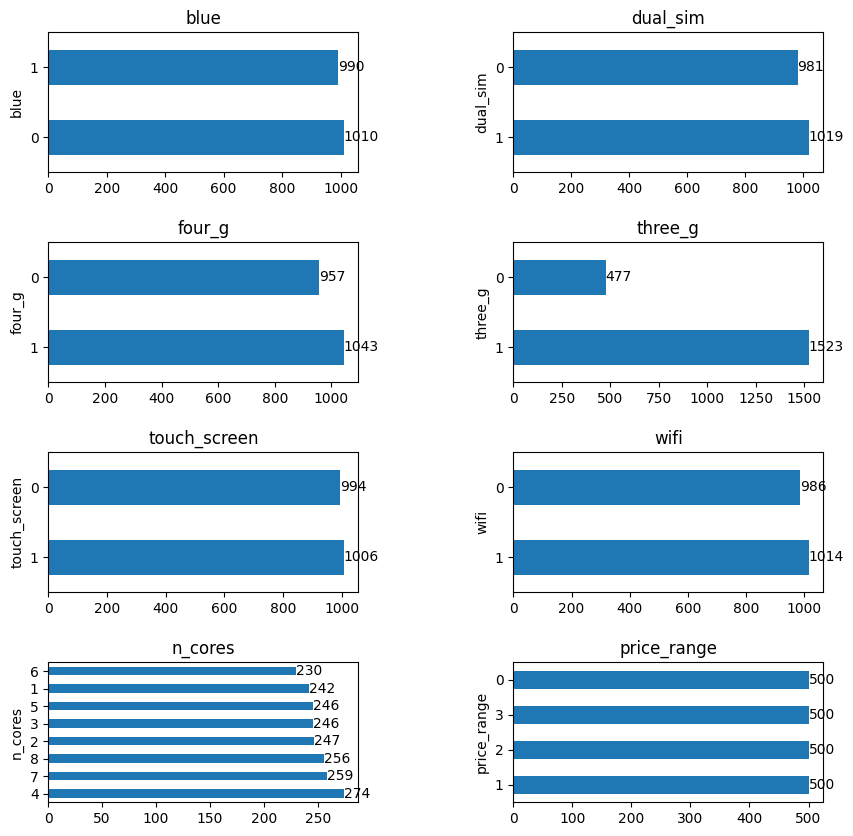

In [28]:
lista_categoricas = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi', 'n_cores', 'price_range']

fig, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (10, 10))

plt.subplots_adjust(
    wspace = 0.5,
    hspace = 0.5
)

for col, ax in zip(data[lista_categoricas], axes.ravel()):
  data[col].value_counts().plot.barh(ax = ax)
  ax.set_title(col)
  ax.bar_label(ax.containers[0])

plt.show()

### **1.3. Escriba el código que permita validar si el dataset está balanceado**

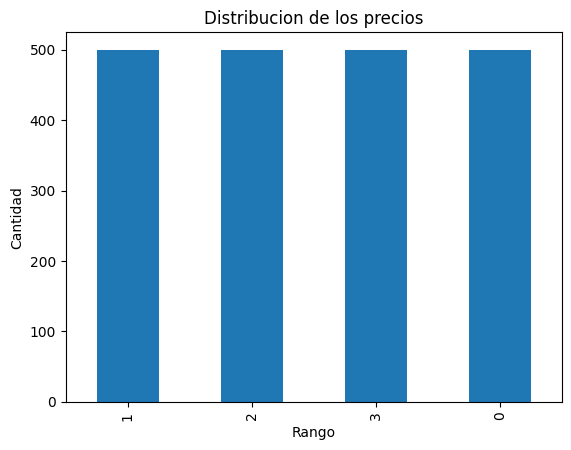

In [29]:
# codigo que permita validar si el dataset esta balanceado
data['price_range'].value_counts().plot(kind='bar')
plt.xlabel('Rango')
plt.ylabel('Cantidad')
plt.title('Distribucion de los precios')
plt.show()

## **Dada la grafica anterior, que es la misma que la ultima grafica del paso anterior podemos ver que el dataset tiene la misma cantidad de registros en cada uno de los rangos, por lo tanto podemos ver que el dataset esta balanceado**

# **Preprocesamiento de datos**

In [30]:
# creamos una copia del dataset y verificamos su tamaño
copy_data = data.copy()
copy_data.shape

if copy_data.shape == data.shape:
  print('Son iguales')
else:
  print('No son iguales')

# trabajamos las variables categoricas para agregarlas por separado del dataset que son ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi', 'n_cores', 'price_range']
copy_data_blue = pd.get_dummies(copy_data['blue'], prefix='A', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_blue], axis = 1)

copy_data_dual_sim = pd.get_dummies(copy_data['dual_sim'], prefix='B', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_dual_sim], axis = 1)

copy_data_four_g = pd.get_dummies(copy_data['four_g'], prefix='C', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_four_g], axis = 1)

copy_data_three_g = pd.get_dummies(copy_data['three_g'], prefix='D', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_three_g], axis = 1)

copy_data_touch_screen = pd.get_dummies(copy_data['touch_screen'], prefix='E', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_touch_screen], axis = 1)

copy_data_wifi = pd.get_dummies(copy_data['wifi'], prefix='F', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_wifi], axis = 1)

copy_data_n_cores = pd.get_dummies(copy_data['n_cores'], prefix='G', drop_first = True)
copy_data = pd.concat([copy_data, copy_data_n_cores], axis = 1)

copy_data.drop(['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi', 'n_cores'], axis = 1, inplace = True)

copy_data.info()

Son iguales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   clock_speed    2000 non-null   float64
 2   fc             2000 non-null   int64  
 3   int_memory     2000 non-null   int64  
 4   m_dep          2000 non-null   float64
 5   mobile_wt      2000 non-null   int64  
 6   pc             2000 non-null   int64  
 7   px_height      2000 non-null   int64  
 8   px_width       2000 non-null   int64  
 9   ram            2000 non-null   int64  
 10  sc_h           2000 non-null   int64  
 11  sc_w           2000 non-null   int64  
 12  talk_time      2000 non-null   int64  
 13  price_range    2000 non-null   int64  
 14  A_1            2000 non-null   bool   
 15  B_1            2000 non-null   bool   
 16  C_1            2000 non-null   bool   
 17  D_1            2000 non-null   bool   
 

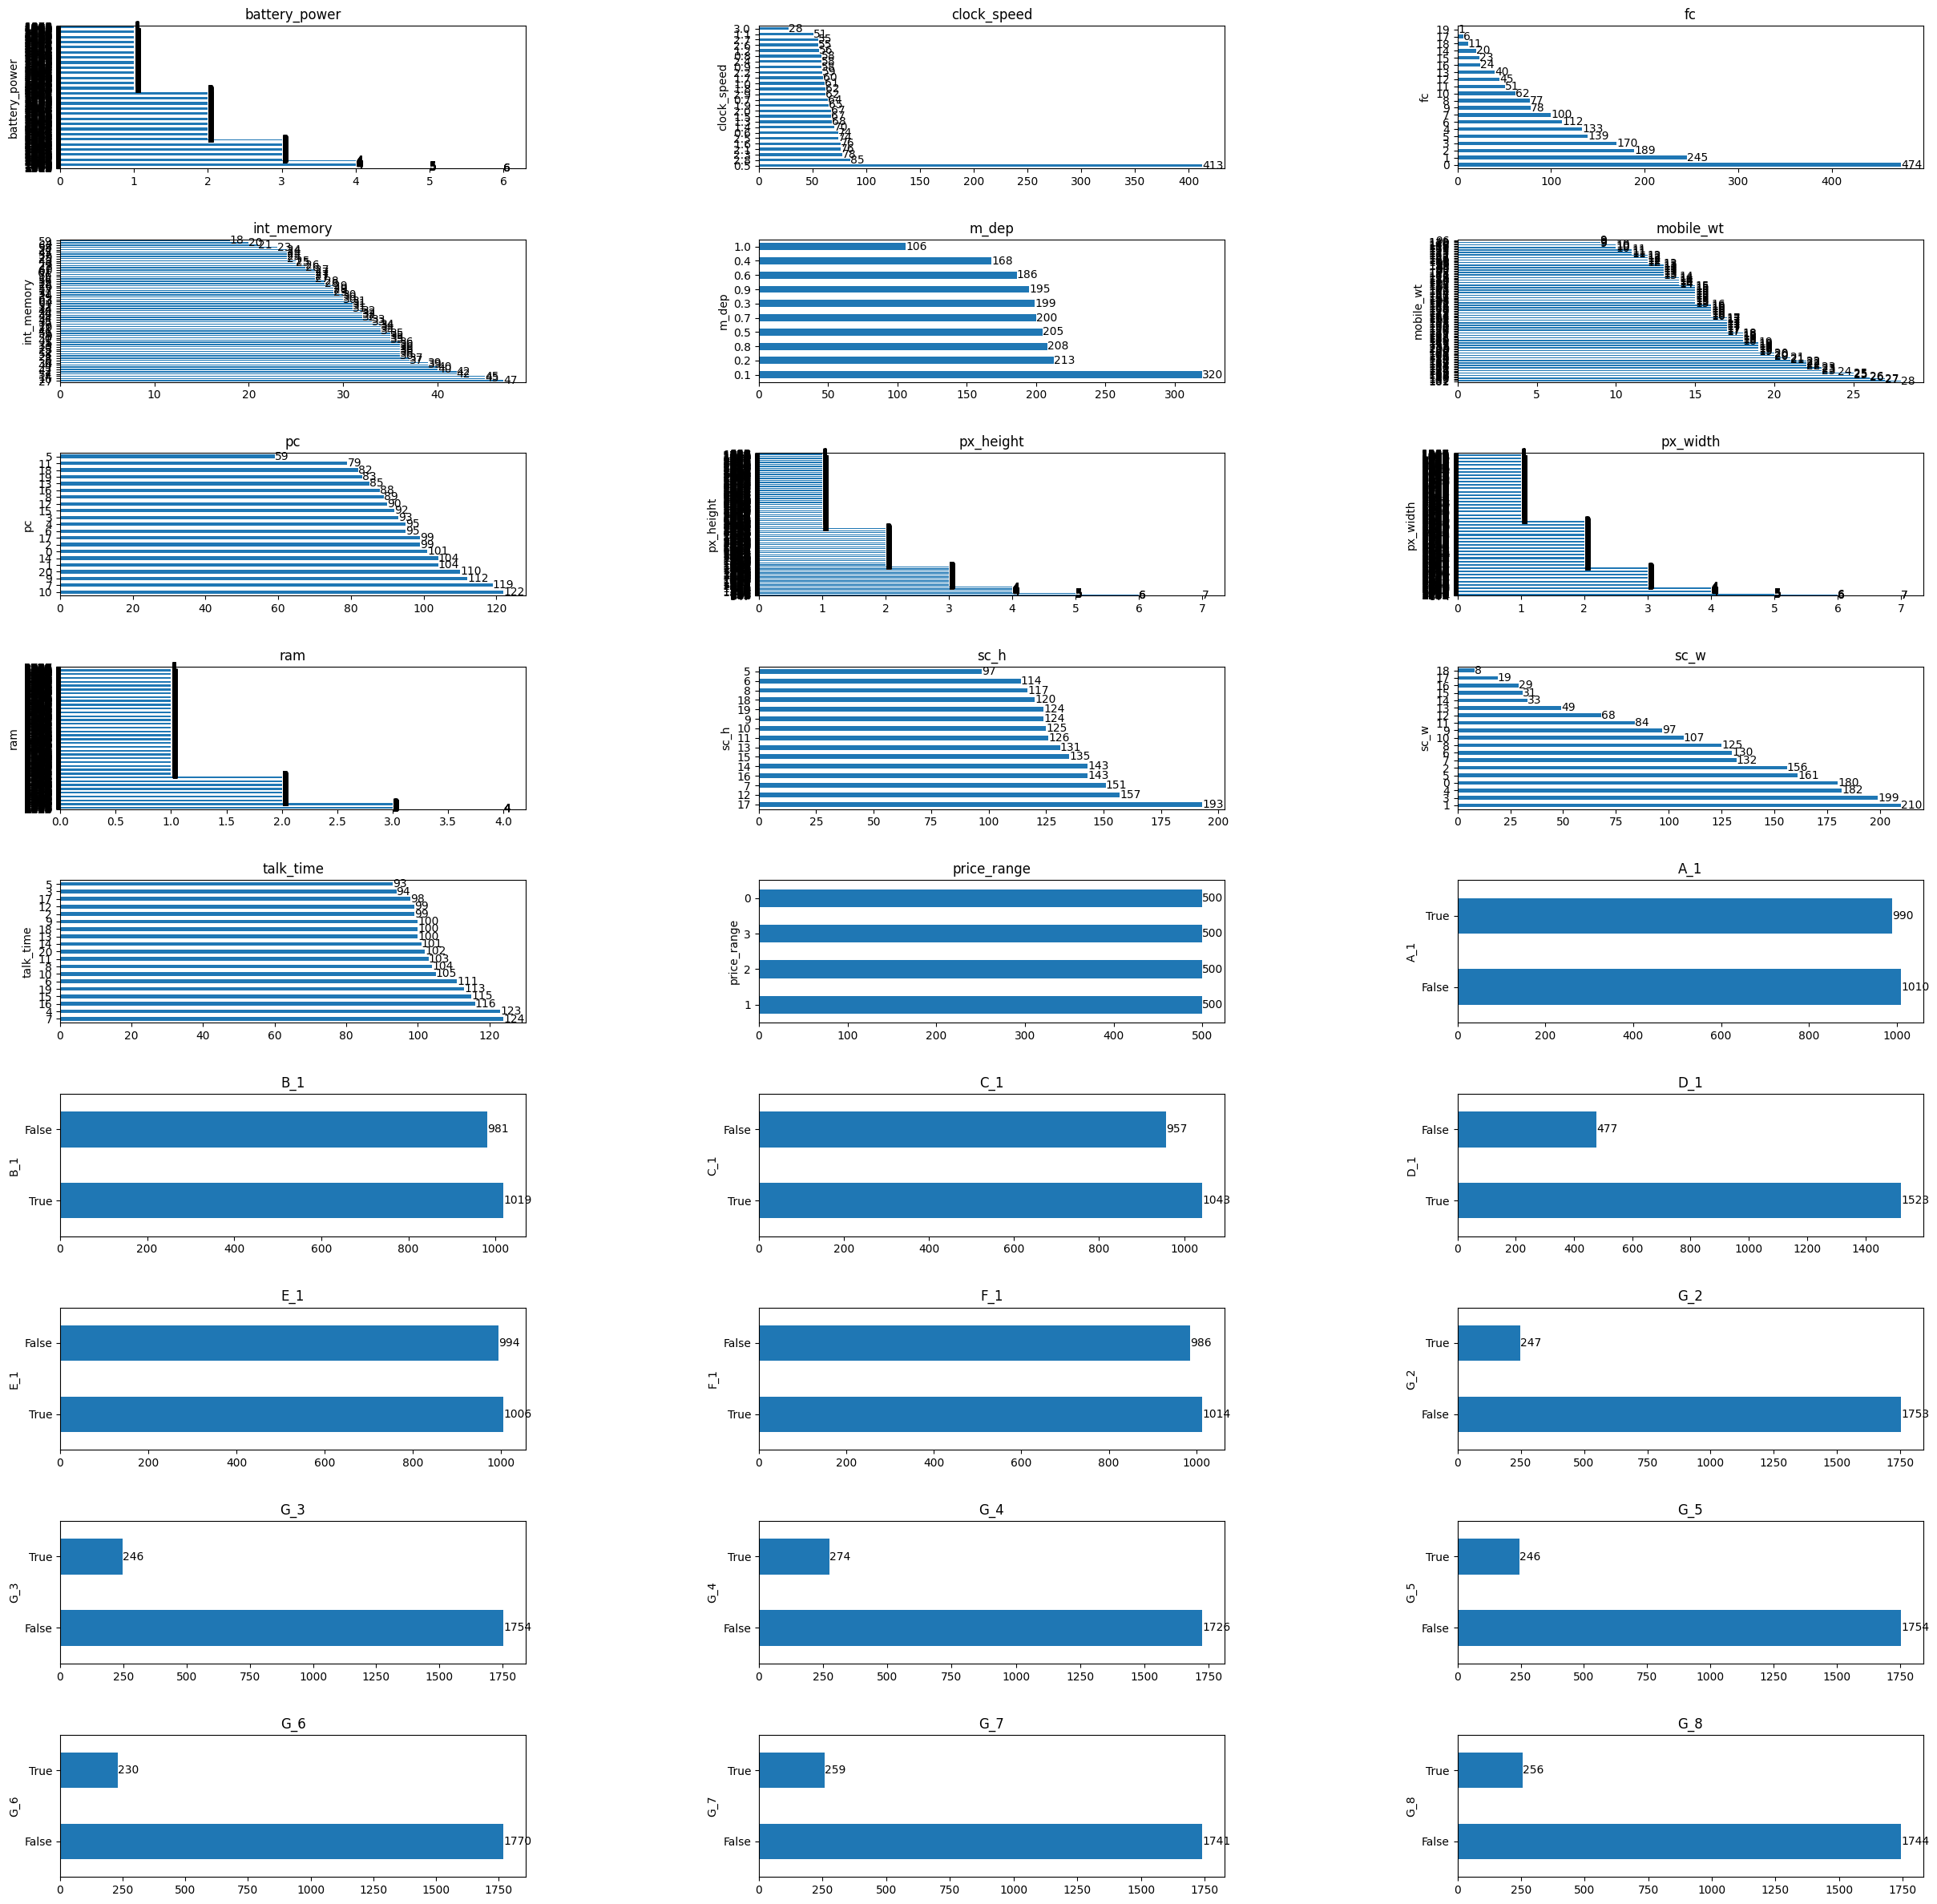

,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,pc,px_height,px_width,ram,...,D_1,E_1,F_1,G_2,G_3,G_4,G_5,G_6,G_7,G_8
0,842,2.2,1,7,0.6,188,2,20,756,2549,...,False,False,True,True,False,False,False,False,False,False
1,1021,0.5,0,53,0.7,136,6,905,1988,2631,...,True,True,False,False,True,False,False,False,False,False
2,563,0.5,2,41,0.9,145,6,1263,1716,2603,...,True,True,False,False,False,False,True,False,False,False
3,615,2.5,0,10,0.8,131,9,1216,1786,2769,...,True,False,False,False,False,False,False,True,False,False
4,1821,1.2,13,44,0.6,141,14,1208,1212,1411,...,True,True,False,True,False,False,False,False,False,False
5,1859,0.5,3,22,0.7,164,7,1004,1654,1067,...,True,False,False,False,False,False,False,False,False,False
6,1821,1.7,4,10,0.8,139,10,381,1018,3220,...,True,False,True,False,False,False,False,False,False,True
7,1954,0.5,0,24,0.8,187,0,512,1149,700,...,True,True,True,False,False,True,False,False,False,False
8,1445,0.5,0,53,0.7,174,14,386,836,1099,...,True,False,False,False,False,False,False,False,True,False
9,509,0.6,2,9,0.1,93,15,1137,1224,513,...,True,False,False,False,False,False,True,False,False,False


In [31]:
# Estadistica del copy_dataset
copy_data.describe()

# viendo de forma grafica la informacion del copy_dataset
# sns.pairplot(copy_data)
fig, axes = plt.subplots(nrows = 9, ncols = 3, figsize = (30, 30))

plt.subplots_adjust(
    wspace = 0.5,
    hspace = 0.5
)

for col, ax in zip(copy_data, axes.ravel()):
  copy_data[col].value_counts().plot.barh(ax = ax)
  ax.set_title(col)
  ax.bar_label(ax.containers[0])

plt.show()

copy_data.head(10)

### Escriba el código que permita reescalar todos los atributos del dataset utilizando la función del StandardScaler:

In [32]:
X = copy_data.drop('price_range', axis=1)
y = copy_data['price_range']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Aplicación de SVM sobre los datos

In [33]:
# Separación de los datos en train y test

X_train, X_test, y_train, y_test = train_test_split(
                                        X_scaled,
                                        y,
                                        train_size   = 0.8,
                                        random_state = 123,
                                        shuffle      = True
                                    )

# Creación del modelo SVM lineal
svm = SVC(kernel = 'linear', C = 1, random_state = 1234)

# Entrenamiento del modelo
svm.fit(X_train, y_train)

# Predicción del modelo
predictSVM = svm.predict(X_test)

### **2.2. Escriba el código que permita hallar la exactitud (accuracy) del modelo SVM anteriormente entrenado:**

In [34]:
print(accuracy_score(y_test, predictSVM))
print(classification_report(y_test, predictSVM))

0.94
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        87
           1       0.92      0.90      0.91       100
           2       0.93      0.94      0.94       116
           3       0.98      0.96      0.97        97

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



### **2.3. Escriba el código que permita encontrar los mejores parámetros para el modelo  SVM, con un param_grid = {'C': np.linspace(0.1, 100, 200), 'kernel': ('linear', 'rbf')**
#### Tunear hiperparámetros

In [35]:
# Parametros y los valores que van a tomar
param_grid = {'C': np.linspace(0.1, 100, 200),
              'kernel': ['linear', 'rbf']
              }

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.944 total time=   0.1s
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.925 total time=   0.1s
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.934 total time=   0.1s
[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.925 total time=   0.1s
[CV 5/5] END ..............C=0.1, kernel=linear;, score=0.916 total time=   0.1s
[CV 1/5] END .................C=0.1, kernel=rbf;, score=0.547 total time=   0.2s
[CV 2/5] END .................C=0.1, kernel=rbf;, score=0.537 total time=   0.2s
[CV 3/5] END .................C=0.1, kernel=rbf;, score=0.566 total time=   0.2s
[CV 4/5] END .................C=0.1, kernel=rbf;, score=0.537 total time=   0.2s
[CV 5/5] END .................C=0.1, kernel=rbf;, score=0.534 total time=   0.2s
[CV 1/5] END C=0.6020100502512563, kernel=linear;, score=0.966 total time=   0.1s
[CV 2/5] END C=0.6020100502512563, kernel=li

GridSearchCV(estimator=SVC(),
             param_grid={'C': array([  0.1       ,   0.60201005,   1.1040201 ,   1.60603015,
         2.1080402 ,   2.61005025,   3.1120603 ,   3.61407035,
         4.1160804 ,   4.61809045,   5.1201005 ,   5.62211055,
         6.1241206 ,   6.62613065,   7.1281407 ,   7.63015075,
         8.1321608 ,   8.63417085,   9.1361809 ,   9.63819095,
        10.14020101,  10.64221106,  11.14422111,  11.64623116,
        12.14824121,  12.65025126,  13.15226131,  13.6542713...
        86.44572864,  86.94773869,  87.44974874,  87.95175879,
        88.45376884,  88.95577889,  89.45778894,  89.95979899,
        90.46180905,  90.9638191 ,  91.46582915,  91.9678392 ,
        92.46984925,  92.9718593 ,  93.47386935,  93.9758794 ,
        94.47788945,  94.9798995 ,  95.48190955,  95.9839196 ,
        96.48592965,  96.9879397 ,  97.48994975,  97.9919598 ,
        98.49396985,  98.9959799 ,  99.49798995, 100.        ]),
                         'kernel': ['linear', 'rbf']},
             verbose=3)


### **2.4. Escriba el código que permita conocer los mejores parámetros encontrados en el ítem anterior**



In [36]:
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 4.11608040201005, 'kernel': 'linear'}
SVC(C=4.11608040201005, kernel='linear')


### **2.5. Escriba el código que permita hallar la exactitud del modelo de SVM aplicando los mejores parámetros**

In [37]:
print(grid.best_estimator_)
best_grid = grid.best_estimator_
predict_best_grid = best_grid.predict(X_test)

# exactitud del modelo
print(accuracy_score(y_test, predict_best_grid))


SVC(C=4.11608040201005, kernel='linear')
0.955


### **2.6. Escriba el código que permita hallar la las métricas del modelo entrenado en el ítem anterior. Utilice la función classification_report**

In [38]:
# etiquetas
class_label = ['0', '1', '2', '3']
print(classification_report(y_test, predict_best_grid, target_names = class_label))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        87
           1       0.92      0.95      0.94       100
           2       0.95      0.93      0.94       116
           3       0.98      0.97      0.97        97

    accuracy                           0.95       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.95      0.96       400



# 3. REDES NEURONALES

### **3.1. Escriba el código que permita entrenar un perceptrón multicapa con 3 capas ocultas con 200, 100 y 50 neuronas respectivamente en cada capa. Función de activación 'Relu' y random_state=1**

In [39]:
# normalizando los datos
scaler_train = MinMaxScaler()
X_train = scaler_train.fit_transform(X_train)

scaler_test = MinMaxScaler()
X_test = scaler_test.fit_transform(X_test)

# Clasificador de red neuronal
mlp_classifier = MLPClassifier(hidden_layer_sizes=(200, 100, 50), activation='relu', random_state=1)
mlp_classifier.fit(X_train, y_train)

# Predicción del modelo
predict_mlp = mlp_classifier.predict(X_test)


### **3.2. Escriba el código que permita hallar la exactitud del modelo de redes neuronales anteriormente entrenado:**

In [40]:
print(accuracy_score(y_test, predict_mlp))

0.925


### **3.3. Escriba el código que permita hallar la las métricas del modelo entrenado en el ítem anterior. Utilice la función classification_report**

In [41]:
print(classification_report(y_test, predict_mlp))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        87
           1       0.95      0.90      0.92       100
           2       0.93      0.91      0.92       116
           3       0.92      0.93      0.92        97

    accuracy                           0.93       400
   macro avg       0.92      0.93      0.93       400
weighted avg       0.93      0.93      0.92       400



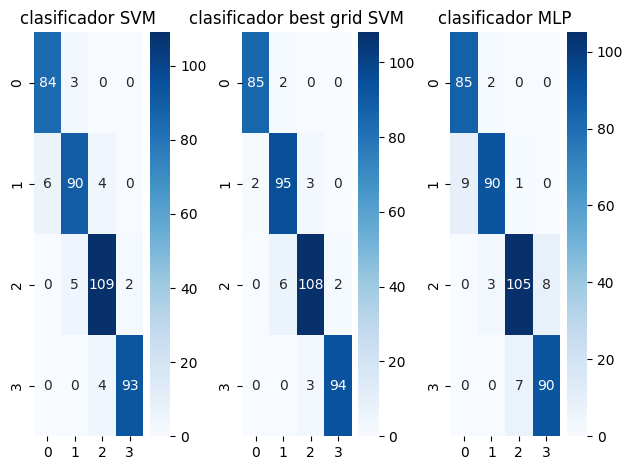

In [42]:
matris_confusion_svm = confusion_matrix(y_test, predictSVM)
matris_confusion_svm_best_grid = confusion_matrix(y_test, predict_best_grid)
matris_confusion_mlp = confusion_matrix(y_test, predict_mlp)

mat_inf = [
    {'type': 'clasificador SVM', 'conf_mat': matris_confusion_svm},
    {'type': 'clasificador best grid SVM', 'conf_mat': matris_confusion_svm_best_grid},
    {'type': 'clasificador MLP', 'conf_mat': matris_confusion_mlp}
]

class_label = ["0", "1", "2", "3"]
n_alg = len(mat_inf)

fig, ax = plt.subplots(1, len(mat_inf))

for i, inf_alg in enumerate(mat_inf):
    c = sns.heatmap(inf_alg['conf_mat'], annot = True, fmt = 'g', cmap=plt.cm.Blues, ax = ax[i])
    c.set(xticklabels=class_label, yticklabels=class_label)
    ax[i].set_title(inf_alg['type'])
plt.tight_layout()
plt.show()

### 4. **Conclusiones**
Aplicando ambos modelos, la máquina de soporte vectorial y el clasificador de redes neuronales puedo hacer 3 conclusiones interesantes:

En la primera máquina de soporte hecha con los parámetros dados por el problema nos arrojó un accuracy de 94% que la verdad es bastante bueno, pero comparado con el resultado obtenido por el ajuste hecho en best grid SVM vemos que hay una mejora que pareciera no significativa de solo el 0.1% esto en la matriz de confusión lo vemos mejor ya que el best grid SVM cometió menos errores que la primera SVM e incluso tuvo un mejor rendimiento que la red neuronal.

Mi segunda conclusión es que para el caso de que queramos hacer un clasificador con una SVM es una muy buena idea hacer el ajuste de los parámetros con el método GridSearchCV para llegar a un buen modelo y que este nos arroje su mejor resultado como lo vimos con el método GridSearchCV.best_estimator_ y poderlo usar de manera rápida.

Mi tercera y última conclusión es que, independientemente de que en este caso no arrojo los mejores resultados, este sigue siendo un buen método para hacer categorizaciones, en este caso el accuracy del MLP fue del 93%, el más bajo de todos los implementados para esta tarea, pero bien podemos jugar con los parámetros dados a la red neuronal para mejorar las métricas de la red neuronal.

Después de hacer esta actividad me siento contento con los resultados y en especial porque pude pasar de ser espectador de las clases y los modelos vistos de SVM y ML a poder entrenar y probar yo por mi cuenta para esta tarea. Me siento contento con el aprendizaje y con el contenido de esta materia, puedo decir que es de las materias que más he disfrutado y aprendido hasta ahora.
